In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('PJM(AEP)_energy_dataset.csv')
df.head()

,Datetime,PJME_MW
0,2002-12-31 01:00:00,26498.0
1,2002-12-31 02:00:00,25147.0
2,2002-12-31 03:00:00,24574.0
3,2002-12-31 04:00:00,24393.0
4,2002-12-31 05:00:00,24860.0


In [11]:
# Classify features
qualitative_features = df.select_dtypes(include=['object']).columns.tolist()
quantitative_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Qualitative Features:", qualitative_features)
print("Quantitative Features:", quantitative_features)

Qualitative Features: [' Datetime']
Quantitative Features: ['PJME_MW']


C:\Users\lenovo\AppData\Local\Temp\ipykernel_7736\277099330.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  qualitative_features = df.select_dtypes(include=['object']).columns.tolist()


In [12]:
# Descriptive statistics
desc = df.describe()
mean_val = df['PJME_MW'].mean()
median_val = df['PJME_MW'].median()
min_val = df['PJME_MW'].min()
max_val = df['PJME_MW'].max()

desc, mean_val, median_val, min_val, max_val

(             PJME_MW
 count  145366.000000
 mean    32080.222831
 std      6464.012166
 min     14544.000000
 25%     27573.000000
 50%     31421.000000
 75%     35650.000000
 max     62009.000000,
 np.float64(32080.222830648156),
 np.float64(31421.0),
 np.float64(14544.0),
 np.float64(62009.0))

In [13]:
# Missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("Duplicate rows:", df.duplicated().sum())

# Create time-based features
df['Hour'] = df.index.hour
df['Day'] = df.index.day
df['Month'] = df.index.month
df['Year'] = df.index.year
df['DayOfWeek'] = df.index.dayofweek

df.head()

Missing values:
  Datetime    0
PJME_MW      0
dtype: int64
Duplicate rows: 0


AttributeError: 'RangeIndex' object has no attribute 'hour'

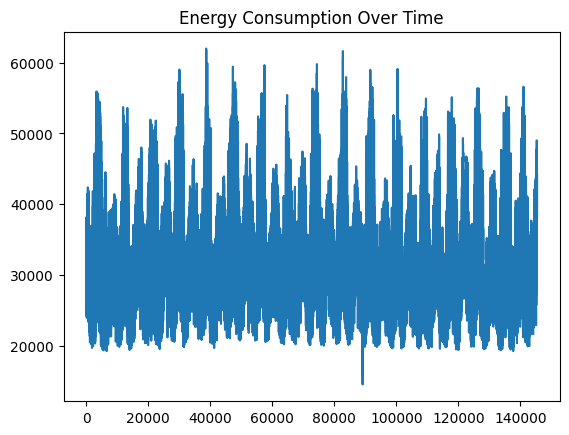

In [14]:
plt.figure()
df['PJME_MW'].plot()
plt.title("Energy Consumption Over Time")
plt.show()

In [ ]:
daily = df['PJME_MW'].resample('D').mean()
monthly = df['PJME_MW'].resample('M').mean()
yearly = df['PJME_MW'].resample('Y').mean()

plt.figure()
daily.plot(title="Daily Average Consumption")
plt.show()

plt.figure()
monthly.plot(title="Monthly Average Consumption")
plt.show()

plt.figure()
yearly.plot(title="Yearly Average Consumption")
plt.show()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'RangeIndex'

In [ ]:
plt.figure()
df.boxplot(column='PJME_MW', by='Month')
plt.title("Monthly Seasonality")
plt.suptitle("")
plt.show()

plt.figure()
df.boxplot(column='PJME_MW', by='DayOfWeek')
plt.title("Weekly Pattern")
plt.suptitle("")
plt.show()

In [ ]:
plt.figure()
df['PJME_MW'].hist(bins=30)
plt.title("Distribution of Energy Consumption")
plt.show()

std_dev = df['PJME_MW'].std()
iqr = df['PJME_MW'].quantile(0.75) - df['PJME_MW'].quantile(0.25)

std_dev, iqr

In [ ]:
rolling_mean = df['PJME_MW'].rolling(window=24).mean()
rolling_std = df['PJME_MW'].rolling(window=24).std()

plt.figure()
rolling_mean.plot(title="Rolling Mean (24 Hours)")
plt.show()

plt.figure()
rolling_std.plot(title="Rolling Std Dev (24 Hours)")
plt.show()

In [ ]:
df['Lag_1'] = df['PJME_MW'].shift(1)
df['Lag_24'] = df['PJME_MW'].shift(24)

from pandas.plotting import autocorrelation_plot
plt.figure()
autocorrelation_plot(df['PJME_MW'].dropna())
plt.title("Autocorrelation Plot")
plt.show()

try:
    from statsmodels.graphics.tsaplots import plot_pacf
    plt.figure()
    plot_pacf(df['PJME_MW'].dropna(), lags=50)
    plt.show()
except:
    print("statsmodels not available for PACF plot")

In [ ]:
try:
    from statsmodels.tsa.seasonal import seasonal_decompose
    decomposition = seasonal_decompose(df['PJME_MW'], model='additive', period=24)

    plt.figure()
    decomposition.trend.plot(title="Trend Component")
    plt.show()

    plt.figure()
    decomposition.seasonal.plot(title="Seasonal Component")
    plt.show()

    plt.figure()
    decomposition.resid.plot(title="Residual Component")
    plt.show()
except:
    print("statsmodels not available for decomposition")